In [2]:
from pathlib import Path
import sys

import joblib
import json
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    average_precision_score,
    confusion_matrix,
    f1_score,
    log_loss,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, StratifiedKFold


def find_project_root(start=None):
    """현재 실행 위치에서 Team-7 루트 폴더를 찾아 경로 오류를 줄입니다."""
    start = Path.cwd() if start is None else Path(start).resolve()
    candidates = [start, *start.parents]

    for candidate in candidates:
        if (candidate / "data" / "data_team7.csv").exists():
            return candidate

    raise FileNotFoundError(
        "data/data_team7.csv를 찾지 못했습니다. "
        "노트북을 Team-7 리포지토리 안에서 실행하고 있는지 확인해주세요."
    )


PROJECT_ROOT = find_project_root()
sys.path.insert(0, str(PROJECT_ROOT))

from data.preprocessing_fe import get_hr_data_fe

RANDOM_STATE = 42
DATA_PATH = PROJECT_ROOT / "data" / "data_team7.csv"
RESULTS_DIR = PROJECT_ROOT / "results"
FE_RESULTS_DIR = RESULTS_DIR / "lgbm_fe_experiments"
FE_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"DATA_PATH: {DATA_PATH}")
print(f"FE_RESULTS_DIR: {FE_RESULTS_DIR}")


def evaluate_binary_model(y_true, y_prob, threshold):
    """확률 예측값과 threshold를 받아 공통 성능 지표를 계산합니다."""
    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    return {
        "Threshold": round(float(threshold), 4),
        "Precision": round(precision_score(y_true, y_pred, zero_division=0), 4),
        "Recall": round(recall_score(y_true, y_pred, zero_division=0), 4),
        "F1": round(f1_score(y_true, y_pred, zero_division=0), 4),
        "ROC-AUC": round(roc_auc_score(y_true, y_prob), 4),
        "PR-AUC": round(average_precision_score(y_true, y_prob), 4),
        "LogLoss": round(log_loss(y_true, y_prob), 4),
        "TN": int(tn),
        "FP": int(fp),
        "FN": int(fn),
        "TP": int(tp),
        "ConfusionMatrix": cm,
    }


def find_best_f1_threshold(y_true, y_prob):
    """Validation set에서 F1이 가장 커지는 threshold를 찾습니다."""
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_prob)

    # precision_recall_curve의 thresholds는 precision/recall보다 길이가 1 작습니다.
    f1_scores = 2 * precisions[:-1] * recalls[:-1] / (
        precisions[:-1] + recalls[:-1] + 1e-10
    )

    best_idx = np.argmax(f1_scores)
    return thresholds[best_idx], f1_scores[best_idx]


def normalize_binary_target(y):
    """타깃값이 Yes/No 문자열이어도 항상 0/1 정수 Series로 맞춥니다."""
    y = pd.Series(y).replace({"Yes": 1, "No": 0}).astype(int)
    return y


def calculate_scale_pos_weight(y_train):
    """LightGBM 클래스 불균형 가중치를 안전하게 계산합니다."""
    y_train = normalize_binary_target(y_train)
    negative_count = int((y_train == 0).sum())
    positive_count = int((y_train == 1).sum())

    print(f"target distribution: negative={negative_count}, positive={positive_count}")

    if positive_count == 0:
        raise ValueError(
            "y_train에 positive class(Attrition=1)가 없습니다. "
            "타깃 인코딩이나 데이터 분할 결과를 확인해주세요."
        )

    return negative_count / positive_count


def load_fe_data():
    """FE 전처리 데이터를 불러오고 feature name까지 함께 반환합니다."""
    X_train, X_valid, X_test, y_train, y_valid, y_test, feature_names = get_hr_data_fe(
        DATA_PATH,
        model_type="lgbm_tabnet",
        return_feature_names=True,
    )

    # preprocessing_fe.py에서 이미 변환하지만, 노트북 실행 순서/캐시 문제를 막기 위해 한 번 더 보정합니다.
    y_train = normalize_binary_target(y_train)
    y_valid = normalize_binary_target(y_valid)
    y_test = normalize_binary_target(y_test)

    X_train_df = pd.DataFrame(X_train, columns=feature_names)
    X_valid_df = pd.DataFrame(X_valid, columns=feature_names)
    X_test_df = pd.DataFrame(X_test, columns=feature_names)

    return X_train_df, X_valid_df, X_test_df, y_train, y_valid, y_test, feature_names


def make_lgbm_base_model(y_train):
    """클래스 불균형 비율을 반영한 LightGBM 기본 모델을 생성합니다."""
    scale_pos_weight = calculate_scale_pos_weight(y_train)
    print(f"scale_pos_weight: {scale_pos_weight:.4f}")

    return lgb.LGBMClassifier(
        objective="binary",
        random_state=RANDOM_STATE,
        scale_pos_weight=scale_pos_weight,
        n_estimators=100,
        min_child_samples=10,
        verbose=-1,
    )


def summarize_best_model(model, X_valid, X_test, y_valid, y_test, model_name, search_method, cv_best_score):
    """Validation에서 threshold를 정하고 Test 성능까지 같은 형식으로 정리합니다."""
    y_valid_prob = model.predict_proba(X_valid)[:, 1]
    best_threshold, best_valid_f1 = find_best_f1_threshold(y_valid, y_valid_prob)

    y_test_prob = model.predict_proba(X_test)[:, 1]
    valid_result = evaluate_binary_model(y_valid, y_valid_prob, best_threshold)
    test_result = evaluate_binary_model(y_test, y_test_prob, best_threshold)

    rows = []
    for dataset_name, result in [("Validation", valid_result), ("Test", test_result)]:
        rows.append({
            "Model": model_name,
            "Feature Set": "FE",
            "Search Method": search_method,
            "Dataset": dataset_name,
            "CV Best PR-AUC": round(float(cv_best_score), 4),
            **{k: v for k, v in result.items() if k != "ConfusionMatrix"},
        })

    summary_df = pd.DataFrame(rows)
    print(f"Best threshold: {best_threshold:.4f}")
    print(f"Validation best F1: {best_valid_f1:.4f}")
    display(summary_df)

    print("[Validation Confusion Matrix]")
    print(valid_result["ConfusionMatrix"])
    print("[Test Confusion Matrix]")
    print(test_result["ConfusionMatrix"])

    return summary_df


c:\Users\sonju\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PROJECT_ROOT: c:\Users\sonju\Documents\과제물, 수업 자료\3학년\3-2\기계학습기초\팀프로젝트\Team-7
DATA_PATH: c:\Users\sonju\Documents\과제물, 수업 자료\3학년\3-2\기계학습기초\팀프로젝트\Team-7\data\data_team7.csv
FE_RESULTS_DIR: c:\Users\sonju\Documents\과제물, 수업 자료\3학년\3-2\기계학습기초\팀프로젝트\Team-7\results\lgbm_fe_experiments


### 그리드서치

In [3]:
def run_lgbm_gridsearch_fe():
    """FE 데이터로 GridSearchCV 튜닝을 수행합니다."""
    print("1. FE 데이터 로드")
    X_train, X_valid, X_test, y_train, y_valid, y_test, feature_names = load_fe_data()

    base_model = make_lgbm_base_model(y_train)

    param_grid = {
        "learning_rate": [0.05, 0.1, 0.2],
        "max_depth": [3, 5, 7],
        "num_leaves": [7, 15, 31],
        "reg_alpha": [0, 0.1, 1],
        "reg_lambda": [0, 0.1, 1],
    }

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

    print("2. GridSearchCV 실행: 기준 지표 = PR-AUC")
    grid_search_fe = GridSearchCV(
        estimator=base_model,
        param_grid=param_grid,
        scoring="average_precision",
        cv=cv,
        n_jobs=-1,
        verbose=1,
        refit=True,
    )
    grid_search_fe.fit(X_train, y_train)

    print("\n3. 최적 하이퍼파라미터")
    print(grid_search_fe.best_params_)
    print(f"CV Best PR-AUC: {grid_search_fe.best_score_:.4f}")

    tuning_results = pd.DataFrame(grid_search_fe.cv_results_)[[
        "rank_test_score", "mean_test_score", "std_test_score",
        "param_learning_rate", "param_max_depth", "param_num_leaves",
        "param_reg_alpha", "param_reg_lambda",
    ]].sort_values("rank_test_score")

    display(tuning_results.head(10))
    tuning_results.to_csv(FE_RESULTS_DIR / "lgbm_grid_fe_tuning_results.csv", index=False, encoding="utf-8-sig")

    grid_summary_fe = summarize_best_model(
        grid_search_fe.best_estimator_,
        X_valid,
        X_test,
        y_valid,
        y_test,
        model_name="LightGBM",
        search_method="GridSearchCV",
        cv_best_score=grid_search_fe.best_score_,
    )
    grid_summary_fe.to_csv(FE_RESULTS_DIR / "lgbm_grid_fe_summary.csv", index=False, encoding="utf-8-sig")

    return grid_search_fe.best_estimator_, grid_search_fe, grid_summary_fe, feature_names


grid_lgbm_fe, grid_search_fe, grid_summary_fe, feature_names_fe = run_lgbm_gridsearch_fe()


1. FE 데이터 로드
target distribution: negative=863, positive=166
scale_pos_weight: 5.1988
2. GridSearchCV 실행: 기준 지표 = PR-AUC
Fitting 5 folds for each of 243 candidates, totalling 1215 fits

3. 최적 하이퍼파라미터
{'learning_rate': 0.2, 'max_depth': 5, 'num_leaves': 31, 'reg_alpha': 1, 'reg_lambda': 1}
CV Best PR-AUC: 0.6121


,rank_test_score,mean_test_score,std_test_score,param_learning_rate,param_max_depth,param_num_leaves,param_reg_alpha,param_reg_lambda
215,1,0.612117,0.051211,0.2,5,31,1.0,1.0
236,2,0.609642,0.042866,0.2,7,31,0.0,1.0
233,3,0.608372,0.050824,0.2,7,15,1.0,1.0
230,4,0.608154,0.049920,0.2,7,15,0.1,1.0
143,5,0.604520,0.067346,0.1,7,7,1.0,1.0
232,6,0.604193,0.063052,0.2,7,15,1.0,0.1
151,7,0.603926,0.051223,0.1,7,15,1.0,0.1
152,8,0.603449,0.051566,0.1,7,15,1.0,1.0
116,9,0.602759,0.055001,0.1,5,7,1.0,1.0
241,10,0.601904,0.061832,0.2,7,31,1.0,0.1


Best threshold: 0.1390
Validation best F1: 0.4578


,Model,Feature Set,Search Method,Dataset,CV Best PR-AUC,Threshold,Precision,Recall,F1,ROC-AUC,PR-AUC,LogLoss,TN,FP,FN,TP
0,LightGBM,FE,GridSearchCV,Validation,0.6121,0.139,0.3958,0.5429,0.4578,0.7489,0.3938,0.4862,156,29,16,19
1,LightGBM,FE,GridSearchCV,Test,0.6121,0.139,0.3103,0.5000,0.3830,0.7191,0.4457,0.5052,145,40,18,18


[Validation Confusion Matrix]
[[156  29]
 [ 16  19]]
[Test Confusion Matrix]
[[145  40]
 [ 18  18]]


### 랜덤서치

In [4]:
def run_lgbm_randomsearch_fe():
    """FE 데이터로 RandomizedSearchCV 튜닝을 수행합니다."""
    print("1. FE 데이터 로드")
    X_train, X_valid, X_test, y_train, y_valid, y_test, feature_names = load_fe_data()

    base_model = make_lgbm_base_model(y_train)

    param_distributions = {
        "learning_rate": [0.005, 0.01, 0.05, 0.1, 0.2],
        "max_depth": [3, 5, 7, 9, -1],
        "num_leaves": [7, 15, 31, 63, 127],
        "subsample": [0.7, 0.8, 0.9, 1.0],
        "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
        "reg_alpha": [0, 0.01, 0.1, 1, 5],
        "reg_lambda": [0, 0.01, 0.1, 1, 5],
    }

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

    print("2. RandomizedSearchCV 실행: 기준 지표 = PR-AUC")
    random_search_fe = RandomizedSearchCV(
        estimator=base_model,
        param_distributions=param_distributions,
        n_iter=50,
        scoring="average_precision",
        cv=cv,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=1,
        refit=True,
    )
    random_search_fe.fit(X_train, y_train)

    print("\n3. 최적 하이퍼파라미터")
    print(random_search_fe.best_params_)
    print(f"CV Best PR-AUC: {random_search_fe.best_score_:.4f}")

    tuning_results = pd.DataFrame(random_search_fe.cv_results_)[[
        "rank_test_score", "mean_test_score", "std_test_score",
        "param_learning_rate", "param_max_depth", "param_num_leaves",
        "param_subsample", "param_colsample_bytree",
        "param_reg_alpha", "param_reg_lambda",
    ]].sort_values("rank_test_score")

    display(tuning_results.head(10))
    tuning_results.to_csv(FE_RESULTS_DIR / "lgbm_random_fe_tuning_results.csv", index=False, encoding="utf-8-sig")

    random_summary_fe = summarize_best_model(
        random_search_fe.best_estimator_,
        X_valid,
        X_test,
        y_valid,
        y_test,
        model_name="LightGBM",
        search_method="RandomizedSearchCV",
        cv_best_score=random_search_fe.best_score_,
    )
    random_summary_fe.to_csv(FE_RESULTS_DIR / "lgbm_random_fe_summary.csv", index=False, encoding="utf-8-sig")

    return random_search_fe.best_estimator_, random_search_fe, random_summary_fe, feature_names


best_lgbm_fe, lgbm_search_fe, lgbm_summary_fe, feature_names_fe = run_lgbm_randomsearch_fe()


1. FE 데이터 로드
target distribution: negative=863, positive=166
scale_pos_weight: 5.1988
2. RandomizedSearchCV 실행: 기준 지표 = PR-AUC
Fitting 5 folds for each of 50 candidates, totalling 250 fits

3. 최적 하이퍼파라미터
{'subsample': 0.7, 'reg_lambda': 5, 'reg_alpha': 0, 'num_leaves': 7, 'max_depth': 7, 'learning_rate': 0.2, 'colsample_bytree': 0.7}
CV Best PR-AUC: 0.6133


,rank_test_score,mean_test_score,std_test_score,param_learning_rate,param_max_depth,param_num_leaves,param_subsample,param_colsample_bytree,param_reg_alpha,param_reg_lambda
48,1,0.613323,0.058153,0.20,7,7,0.7,0.7,0.00,5.00
9,2,0.609148,0.069244,0.10,-1,15,1.0,1.0,5.00,0.10
41,3,0.605943,0.075817,0.10,9,31,0.8,0.8,1.00,5.00
8,4,0.602897,0.040135,0.10,9,127,0.9,0.8,1.00,0.00
30,5,0.600122,0.053603,0.05,9,15,0.9,0.8,0.00,5.00
43,6,0.597831,0.064342,0.10,7,31,0.7,0.7,5.00,1.00
4,7,0.595919,0.052374,0.20,7,31,0.7,0.7,5.00,0.01
27,8,0.595214,0.049304,0.05,5,127,1.0,0.8,0.01,0.10
16,9,0.594477,0.059227,0.05,3,63,1.0,0.7,0.00,0.10
7,10,0.594075,0.086586,0.20,-1,15,0.9,0.9,5.00,1.00


Best threshold: 0.2083
Validation best F1: 0.5000


,Model,Feature Set,Search Method,Dataset,CV Best PR-AUC,Threshold,Precision,Recall,F1,ROC-AUC,PR-AUC,LogLoss,TN,FP,FN,TP
0,LightGBM,FE,RandomizedSearchCV,Validation,0.6133,0.2083,0.3846,0.7143,0.5000,0.7581,0.4260,0.4071,145,40,10,25
1,LightGBM,FE,RandomizedSearchCV,Test,0.6133,0.2083,0.3375,0.7500,0.4655,0.7779,0.5486,0.3998,132,53,9,27


[Validation Confusion Matrix]
[[145  40]
 [ 10  25]]
[Test Confusion Matrix]
[[132  53]
 [  9  27]]


### optuna

In [5]:
def run_lgbm_optuna_fe(n_trials=50):
    """FE 데이터로 Optuna 튜닝을 수행합니다."""
    print("1. FE 데이터 로드")
    X_train, X_valid, X_test, y_train, y_valid, y_test, feature_names = load_fe_data()

    scale_pos_weight = calculate_scale_pos_weight(y_train)
    print(f"scale_pos_weight: {scale_pos_weight:.4f}")

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

    def objective(trial):
        params = {
            "objective": "binary",
            "random_state": RANDOM_STATE,
            "scale_pos_weight": scale_pos_weight,
            "n_estimators": 100,
            "min_child_samples": 10,
            "verbose": -1,
            "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.2, log=True),
            "max_depth": trial.suggest_int("max_depth", 3, 9),
            "num_leaves": trial.suggest_int("num_leaves", 7, 127),
            "subsample": trial.suggest_float("subsample", 0.7, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.7, 1.0),
            "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 5.0),
            "reg_lambda": trial.suggest_float("reg_lambda", 0.0, 5.0),
        }

        pr_auc_scores = []
        for train_idx, val_idx in cv.split(X_train, y_train):
            X_tr = X_train.iloc[train_idx]
            X_va = X_train.iloc[val_idx]
            y_tr = y_train.iloc[train_idx]
            y_va = y_train.iloc[val_idx]

            model = lgb.LGBMClassifier(**params)
            model.fit(X_tr, y_tr)
            y_va_prob = model.predict_proba(X_va)[:, 1]
            pr_auc_scores.append(average_precision_score(y_va, y_va_prob))

        return np.mean(pr_auc_scores)

    print("2. Optuna 실행: 기준 지표 = PR-AUC")
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    optuna_study_fe = optuna.create_study(direction="maximize", study_name="LGBM_FE_Optuna")
    optuna_study_fe.optimize(objective, n_trials=n_trials)

    print("\n3. 최적 하이퍼파라미터")
    print(optuna_study_fe.best_params)
    print(f"CV Best PR-AUC: {optuna_study_fe.best_value:.4f}")

    best_params = {
        **optuna_study_fe.best_params,
        "objective": "binary",
        "random_state": RANDOM_STATE,
        "scale_pos_weight": scale_pos_weight,
        "n_estimators": 100,
        "min_child_samples": 10,
        "verbose": -1,
    }
    optuna_lgbm_fe = lgb.LGBMClassifier(**best_params)
    optuna_lgbm_fe.fit(X_train, y_train)

    optuna_summary_fe = summarize_best_model(
        optuna_lgbm_fe,
        X_valid,
        X_test,
        y_valid,
        y_test,
        model_name="LightGBM",
        search_method="Optuna",
        cv_best_score=optuna_study_fe.best_value,
    )
    optuna_summary_fe.to_csv(FE_RESULTS_DIR / "lgbm_optuna_fe_summary.csv", index=False, encoding="utf-8-sig")

    trials_df = optuna_study_fe.trials_dataframe()
    trials_df.to_csv(FE_RESULTS_DIR / "lgbm_optuna_fe_tuning_results.csv", index=False, encoding="utf-8-sig")

    return optuna_lgbm_fe, optuna_study_fe, optuna_summary_fe, feature_names


optuna_lgbm_fe, optuna_study_fe, optuna_summary_fe, feature_names_fe = run_lgbm_optuna_fe(n_trials=50)


1. FE 데이터 로드
target distribution: negative=863, positive=166
scale_pos_weight: 5.1988
2. Optuna 실행: 기준 지표 = PR-AUC

3. 최적 하이퍼파라미터
{'learning_rate': 0.15357603065597958, 'max_depth': 7, 'num_leaves': 9, 'subsample': 0.8446177646084269, 'colsample_bytree': 0.7318391795545601, 'reg_alpha': 2.500882252228825, 'reg_lambda': 4.121877798220284}
CV Best PR-AUC: 0.6237
Best threshold: 0.2519
Validation best F1: 0.4694


,Model,Feature Set,Search Method,Dataset,CV Best PR-AUC,Threshold,Precision,Recall,F1,ROC-AUC,PR-AUC,LogLoss,TN,FP,FN,TP
0,LightGBM,FE,Optuna,Validation,0.6237,0.2519,0.3651,0.6571,0.4694,0.7325,0.3710,0.4406,145,40,12,23
1,LightGBM,FE,Optuna,Test,0.6237,0.2519,0.3714,0.7222,0.4906,0.7782,0.5391,0.4043,141,44,10,26


[Validation Confusion Matrix]
[[145  40]
 [ 12  23]]
[Test Confusion Matrix]
[[141  44]
 [ 10  26]]


### LGBM 최종 학습 실험 및 시각화

최적 파라미터를 모아 같은 기준으로 모델을 학습. 
Validation set에서 F1이 최대가 되는 threshold를 선택하고, Test set에서 최종 성능과 시각화 결과를 저장



===== grid_search_fe 최종 학습 시작 =====


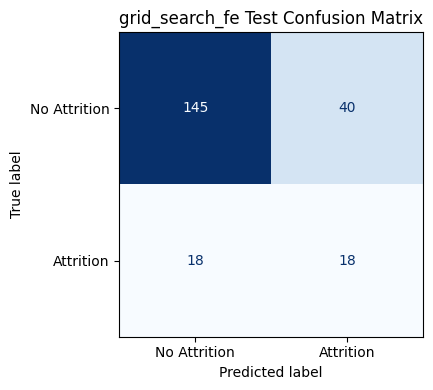

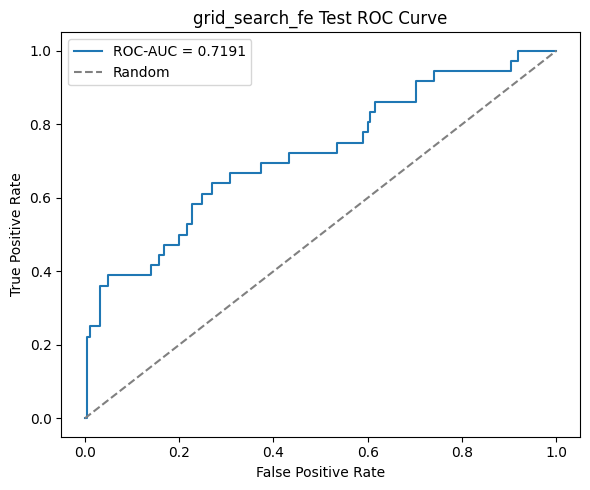

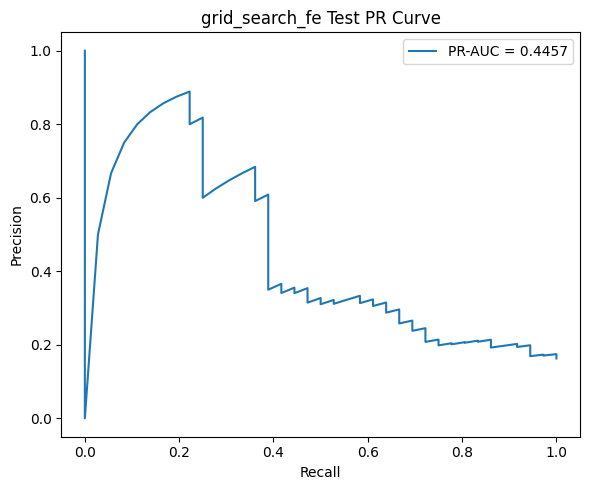

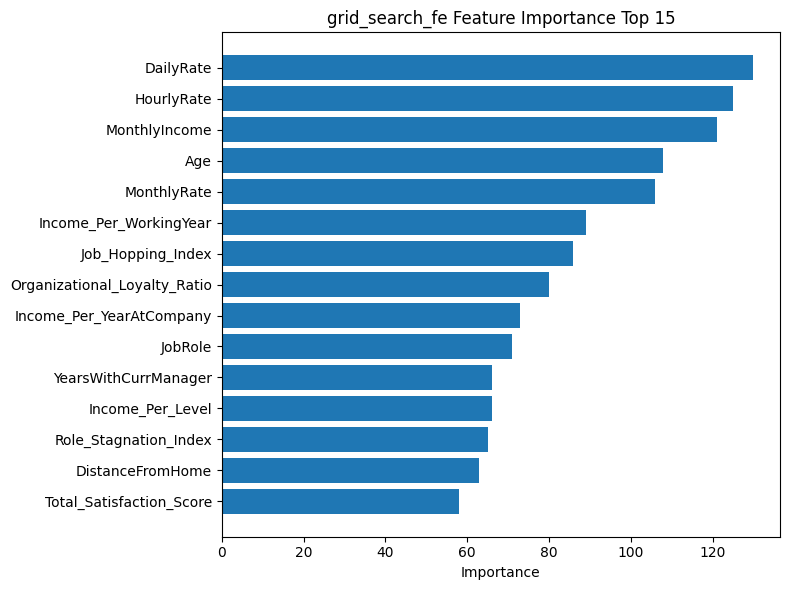

Best threshold: 0.1390
Validation F1: 0.4578
Test F1: 0.3830
Test PR-AUC: 0.4457
Top 5 features:


,Feature,Importance
1,DailyRate,130
5,HourlyRate,125
9,MonthlyIncome,121
0,Age,108
10,MonthlyRate,106



===== random_search_fe 최종 학습 시작 =====


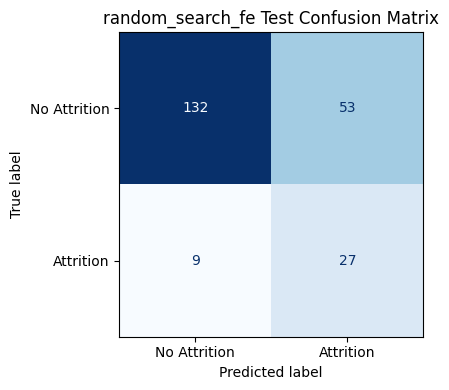

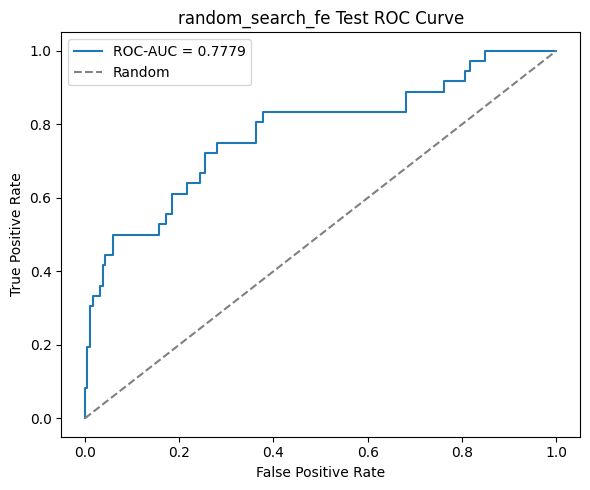

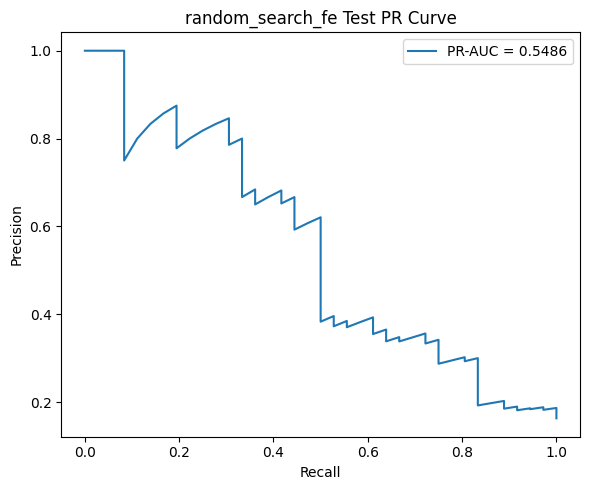

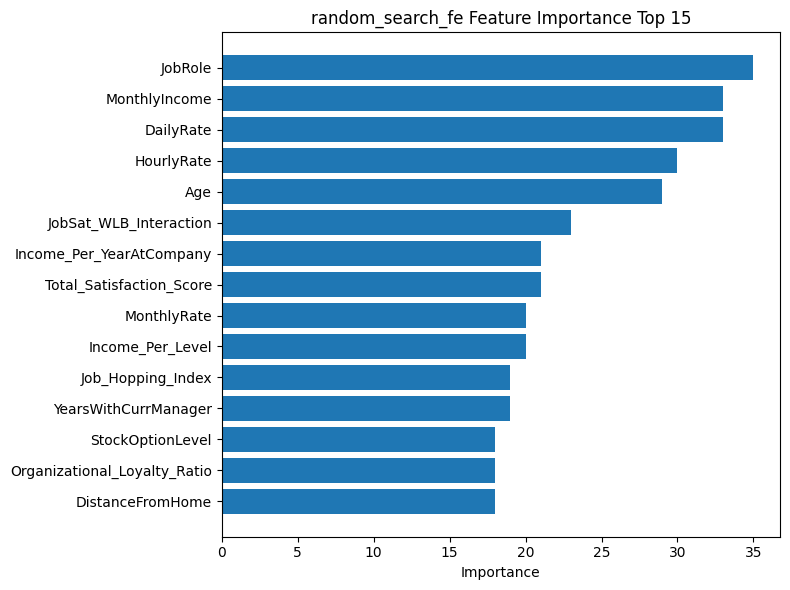

Best threshold: 0.2083
Validation F1: 0.5000
Test F1: 0.4655
Test PR-AUC: 0.5486
Top 5 features:


,Feature,Importance
41,JobRole,35
1,DailyRate,33
9,MonthlyIncome,33
5,HourlyRate,30
0,Age,29



===== optuna_fe 최종 학습 시작 =====


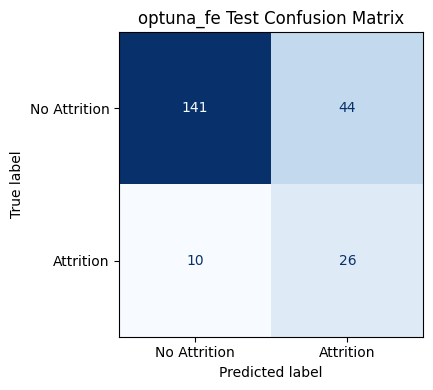

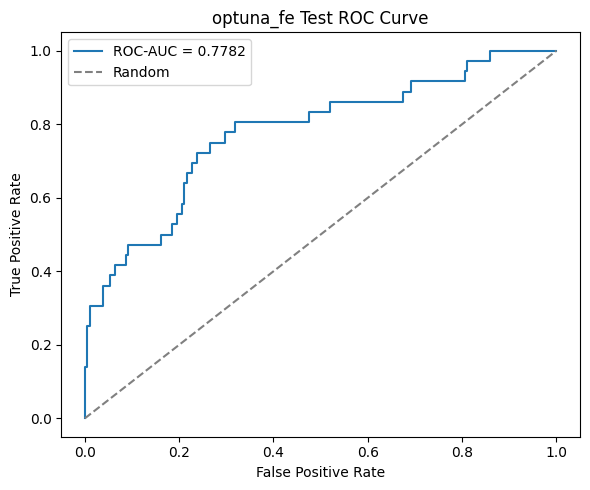

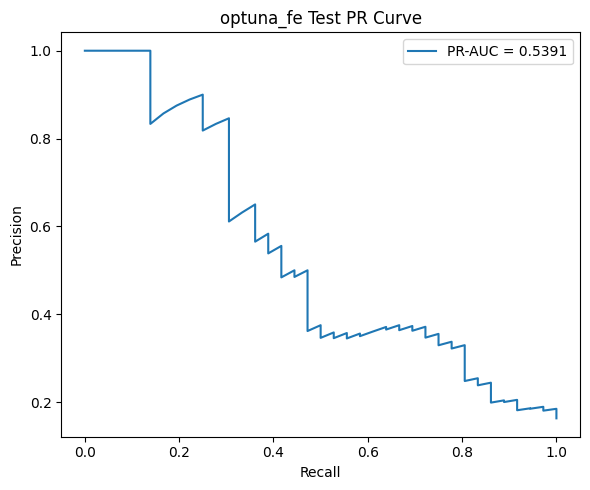

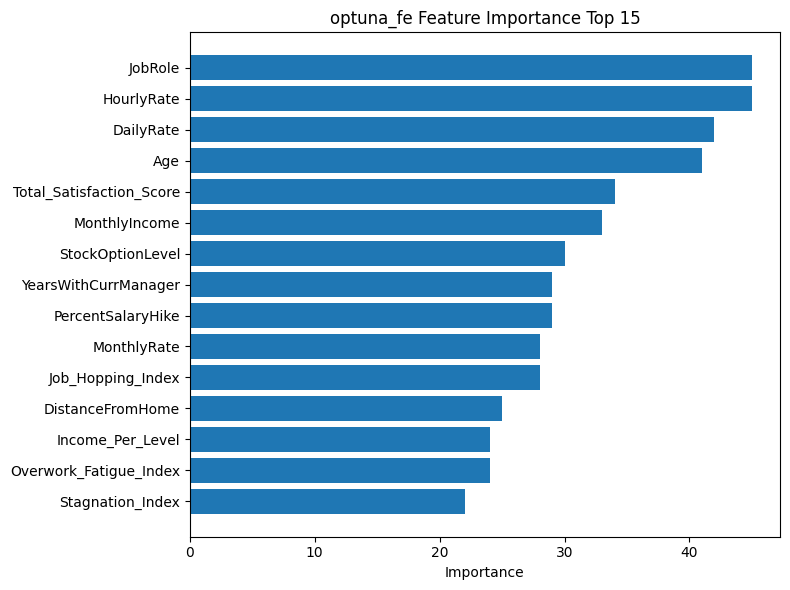

Best threshold: 0.2519
Validation F1: 0.4694
Test F1: 0.4906
Test PR-AUC: 0.5391
Top 5 features:


,Feature,Importance
5,HourlyRate,45
41,JobRole,45
1,DailyRate,42
0,Age,41
34,Total_Satisfaction_Score,34



===== LGBM FE 최종 실험 요약 =====


,Model,Feature Set,Attempt,Search Method,Dataset,CV Best PR-AUC,Threshold,Precision,Recall,F1,ROC-AUC,PR-AUC,LogLoss,TN,FP,FN,TP
0,LightGBM,FE,grid_search_fe,GridSearchCV,Validation,0.6121,0.1390,0.3958,0.5429,0.4578,0.7489,0.3938,0.4862,156,29,16,19
1,LightGBM,FE,grid_search_fe,GridSearchCV,Test,0.6121,0.1390,0.3103,0.5000,0.3830,0.7191,0.4457,0.5052,145,40,18,18
2,LightGBM,FE,random_search_fe,RandomizedSearchCV,Validation,0.6133,0.2083,0.3846,0.7143,0.5000,0.7581,0.4260,0.4071,145,40,10,25
3,LightGBM,FE,random_search_fe,RandomizedSearchCV,Test,0.6133,0.2083,0.3375,0.7500,0.4655,0.7779,0.5486,0.3998,132,53,9,27
4,LightGBM,FE,optuna_fe,Optuna,Validation,0.6237,0.2519,0.3651,0.6571,0.4694,0.7325,0.3710,0.4406,145,40,12,23
5,LightGBM,FE,optuna_fe,Optuna,Test,0.6237,0.2519,0.3714,0.7222,0.4906,0.7782,0.5391,0.4043,141,44,10,26



결과 저장 위치: c:\Users\sonju\Documents\과제물, 수업 자료\3학년\3-2\기계학습기초\팀프로젝트\Team-7\results\lgbm_fe_experiments


In [6]:
def save_confusion_matrix_plot(y_true, y_prob, threshold, save_path, title):
    """선택된 threshold 기준의 confusion matrix를 이미지로 저장합니다."""
    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)

    fig, ax = plt.subplots(figsize=(5, 4))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Attrition", "Attrition"])
    disp.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)
    ax.set_title(title)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()
    plt.close()


def save_roc_curve_plot(y_true, y_prob, save_path, title):
    """ROC curve를 그리고 ROC-AUC 값을 함께 표시합니다."""
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = roc_auc_score(y_true, y_prob)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc:.4f}")
    plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()
    plt.close()


def save_pr_curve_plot(y_true, y_prob, save_path, title):
    """PR curve를 그리고 PR-AUC 값을 함께 표시합니다."""
    precision, recall, _ = precision_recall_curve(y_true, y_prob)
    pr_auc = average_precision_score(y_true, y_prob)

    plt.figure(figsize=(6, 5))
    plt.plot(recall, precision, label=f"PR-AUC = {pr_auc:.4f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()
    plt.close()


def save_feature_importance_plot(model, feature_names, save_csv_path, save_png_path, title):
    """LightGBM feature importance를 CSV와 Top 15 막대그래프로 저장합니다."""
    importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": model.feature_importances_,
    }).sort_values("Importance", ascending=False)

    importance_df.to_csv(save_csv_path, index=False, encoding="utf-8-sig")

    top_df = importance_df.head(15).sort_values("Importance")
    plt.figure(figsize=(8, 6))
    plt.barh(top_df["Feature"], top_df["Importance"])
    plt.xlabel("Importance")
    plt.title(title)
    plt.tight_layout()
    plt.savefig(save_png_path, dpi=150)
    plt.show()
    plt.close()

    return importance_df


def build_fe_attempts_from_tuning_results():
    """앞선 FE 튜닝 결과 객체에서 각 방식의 최적 파라미터를 모읍니다."""
    attempts = []

    if "grid_search_fe" in globals():
        attempts.append({
            "Attempt": "grid_search_fe",
            "Search Method": "GridSearchCV",
            "CV Best PR-AUC": grid_search_fe.best_score_,
            "Params": grid_search_fe.best_params_,
        })

    if "lgbm_search_fe" in globals():
        attempts.append({
            "Attempt": "random_search_fe",
            "Search Method": "RandomizedSearchCV",
            "CV Best PR-AUC": lgbm_search_fe.best_score_,
            "Params": lgbm_search_fe.best_params_,
        })

    if "optuna_study_fe" in globals():
        attempts.append({
            "Attempt": "optuna_fe",
            "Search Method": "Optuna",
            "CV Best PR-AUC": optuna_study_fe.best_value,
            "Params": optuna_study_fe.best_params,
        })

    if not attempts:
        raise RuntimeError("FE 튜닝 결과 객체를 찾지 못했습니다. 위쪽 튜닝 셀을 먼저 실행해주세요.")

    return attempts


def run_final_lgbm_fe_experiments():
    """FE 튜닝 방식별 최적 파라미터로 최종 모델과 시각화를 저장합니다."""
    X_train, X_valid, X_test, y_train, y_valid, y_test, feature_names = load_fe_data()
    scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
    attempts = build_fe_attempts_from_tuning_results()

    all_results = []

    for attempt in attempts:
        attempt_name = attempt["Attempt"]
        attempt_dir = FE_RESULTS_DIR / attempt_name
        attempt_dir.mkdir(parents=True, exist_ok=True)

        print(f"\n===== {attempt_name} 최종 학습 시작 =====")

        params = {
            "objective": "binary",
            "random_state": RANDOM_STATE,
            "scale_pos_weight": scale_pos_weight,
            "n_estimators": 100,
            "min_child_samples": 10,
            "verbose": -1,
            **attempt["Params"],
        }

        model = lgb.LGBMClassifier(**params)
        model.fit(X_train, y_train)

        y_valid_prob = model.predict_proba(X_valid)[:, 1]
        best_threshold, best_valid_f1 = find_best_f1_threshold(y_valid, y_valid_prob)
        y_test_prob = model.predict_proba(X_test)[:, 1]

        valid_result = evaluate_binary_model(y_valid, y_valid_prob, best_threshold)
        test_result = evaluate_binary_model(y_test, y_test_prob, best_threshold)

        for dataset_name, result in [("Validation", valid_result), ("Test", test_result)]:
            all_results.append({
                "Model": "LightGBM",
                "Feature Set": "FE",
                "Attempt": attempt_name,
                "Search Method": attempt["Search Method"],
                "Dataset": dataset_name,
                "CV Best PR-AUC": round(float(attempt["CV Best PR-AUC"]), 4),
                **{k: v for k, v in result.items() if k != "ConfusionMatrix"},
            })

        with open(attempt_dir / "params.json", "w", encoding="utf-8") as f:
            json.dump(params, f, indent=4, ensure_ascii=False)
        joblib.dump(model, attempt_dir / "model.joblib")

        save_confusion_matrix_plot(
            y_test,
            y_test_prob,
            best_threshold,
            attempt_dir / "test_confusion_matrix.png",
            f"{attempt_name} Test Confusion Matrix",
        )
        save_roc_curve_plot(y_test, y_test_prob, attempt_dir / "test_roc_curve.png", f"{attempt_name} Test ROC Curve")
        save_pr_curve_plot(y_test, y_test_prob, attempt_dir / "test_pr_curve.png", f"{attempt_name} Test PR Curve")

        importance_df = save_feature_importance_plot(
            model,
            feature_names,
            attempt_dir / "feature_importance.csv",
            attempt_dir / "feature_importance_top15.png",
            f"{attempt_name} Feature Importance Top 15",
        )

        print(f"Best threshold: {best_threshold:.4f}")
        print(f"Validation F1: {valid_result['F1']:.4f}")
        print(f"Test F1: {test_result['F1']:.4f}")
        print(f"Test PR-AUC: {test_result['PR-AUC']:.4f}")
        print("Top 5 features:")
        display(importance_df.head(5))

    final_summary_fe = pd.DataFrame(all_results)
    final_summary_fe.to_csv(FE_RESULTS_DIR / "lgbm_fe_final_experiment_summary.csv", index=False, encoding="utf-8-sig")

    print("\n===== LGBM FE 최종 실험 요약 =====")
    display(final_summary_fe)
    print(f"\n결과 저장 위치: {FE_RESULTS_DIR}")

    return final_summary_fe


lgbm_fe_final_summary = run_final_lgbm_fe_experiments()


### 러닝커브 및 Threshold 적정선 분석

아래 셀은 FE 최종 실험 결과 중 Test PR-AUC가 가장 높은 LightGBM 모델을 기준으로 러닝커브와 threshold별 Precision/Recall/F1 변화를 시각화합니다. 러닝커브는 데이터가 더 늘어났을 때 성능 개선 여지가 있는지 확인하는 용도이고, threshold 적정선은 Validation set에서 선택한 분류 기준이 어떤 trade-off를 갖는지 설명하는 용도입니다.


Best attempt by Test PR-AUC: random_search_fe
target distribution: negative=863, positive=166
러닝커브 계산 중입니다.


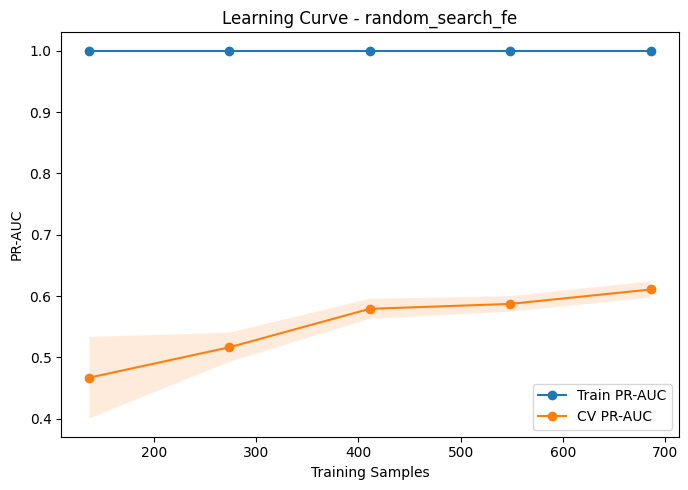

,Train Size,Train PR-AUC Mean,Train PR-AUC Std,CV PR-AUC Mean,CV PR-AUC Std
0,137,1.0,0.000000e+00,0.466923,0.066368
1,274,1.0,0.000000e+00,0.516457,0.023830
2,411,1.0,1.110223e-16,0.579111,0.016257
3,548,1.0,0.000000e+00,0.587091,0.012706
4,686,1.0,1.281975e-16,0.610681,0.013254


Best attempt by Test PR-AUC: random_search_fe
target distribution: negative=863, positive=166


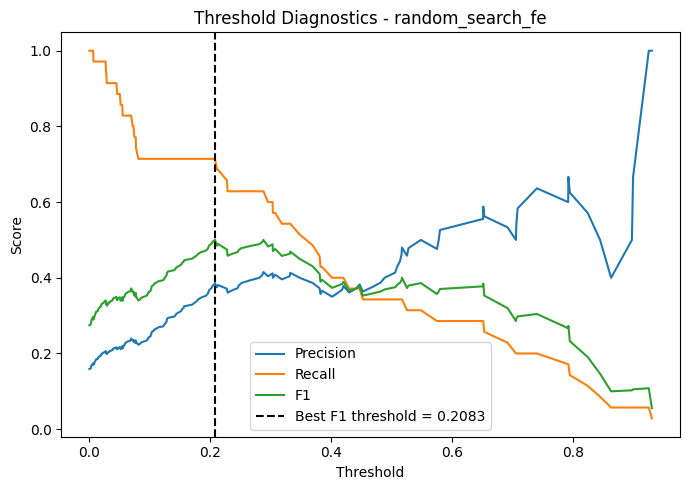

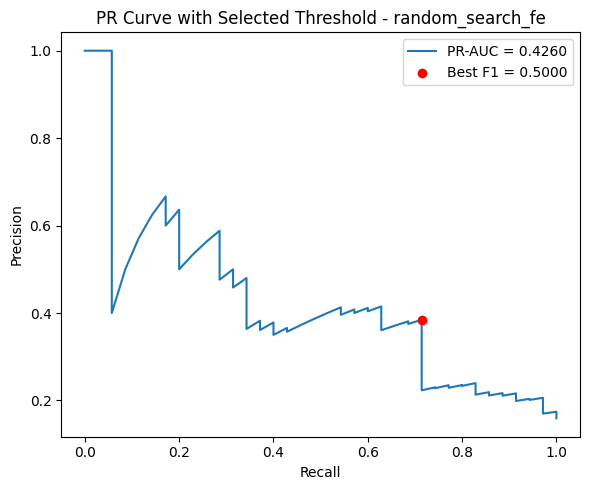

Best threshold: 0.2083
Precision: 0.3846
Recall: 0.7143
F1: 0.5000
결과 저장 위치: c:\Users\sonju\Documents\과제물, 수업 자료\3학년\3-2\기계학습기초\팀프로젝트\Team-7\results\lgbm_fe_experiments\diagnostics


,Threshold,Precision,Recall,F1
155,0.208270,0.384615,0.714286,0.500000
167,0.288522,0.415094,0.628571,0.500000
154,0.204262,0.378788,0.714286,0.495050
166,0.286576,0.407407,0.628571,0.494382
153,0.202687,0.373134,0.714286,0.490196
157,0.213182,0.380952,0.685714,0.489796
165,0.281718,0.400000,0.628571,0.488889
169,0.303587,0.411765,0.600000,0.488372
152,0.198893,0.367647,0.714286,0.485437
156,0.211691,0.375000,0.685714,0.484848


In [8]:
from sklearn.model_selection import learning_curve


DIAGNOSTIC_DIR = FE_RESULTS_DIR / "diagnostics"
DIAGNOSTIC_DIR.mkdir(parents=True, exist_ok=True)


def select_best_fe_attempt(metric="PR-AUC"):
    """최종 요약표가 있으면 Test 기준 최고 모델을, 없으면 CV PR-AUC 최고 모델을 선택합니다."""
    attempts = build_fe_attempts_from_tuning_results()

    if "lgbm_fe_final_summary" in globals():
        test_rows = lgbm_fe_final_summary[lgbm_fe_final_summary["Dataset"] == "Test"].copy()
        if not test_rows.empty and metric in test_rows.columns:
            best_row = test_rows.sort_values(metric, ascending=False).iloc[0]
            best_attempt_name = best_row["Attempt"]
            for attempt in attempts:
                if attempt["Attempt"] == best_attempt_name:
                    print(f"Best attempt by Test {metric}: {best_attempt_name}")
                    return attempt

    best_attempt = max(attempts, key=lambda item: item["CV Best PR-AUC"])
    print(f"Best attempt by CV PR-AUC: {best_attempt['Attempt']}")
    return best_attempt


def make_model_from_fe_attempt(attempt, y_train):
    """선택된 튜닝 결과의 최적 파라미터로 LightGBM 모델을 생성합니다."""
    scale_pos_weight = calculate_scale_pos_weight(y_train)

    params = {
        "objective": "binary",
        "random_state": RANDOM_STATE,
        "scale_pos_weight": scale_pos_weight,
        "n_estimators": 100,
        "min_child_samples": 10,
        "verbose": -1,
        **attempt["Params"],
    }

    return lgb.LGBMClassifier(**params)


def plot_learning_curve_for_best_fe_model():
    """선택 모델의 학습 데이터 크기별 train/CV PR-AUC 변화를 그립니다."""
    X_train, X_valid, X_test, y_train, y_valid, y_test, feature_names = load_fe_data()
    best_attempt = select_best_fe_attempt(metric="PR-AUC")
    model = make_model_from_fe_attempt(best_attempt, y_train)

    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
    train_sizes = np.linspace(0.2, 1.0, 5)

    print("러닝커브 계산 중입니다.")
    sizes, train_scores, cv_scores = learning_curve(
        estimator=model,
        X=X_train,
        y=y_train,
        train_sizes=train_sizes,
        cv=cv,
        scoring="average_precision",
        n_jobs=-1,
        shuffle=True,
        random_state=RANDOM_STATE,
    )

    curve_df = pd.DataFrame({
        "Train Size": sizes,
        "Train PR-AUC Mean": train_scores.mean(axis=1),
        "Train PR-AUC Std": train_scores.std(axis=1),
        "CV PR-AUC Mean": cv_scores.mean(axis=1),
        "CV PR-AUC Std": cv_scores.std(axis=1),
    })
    curve_df.to_csv(DIAGNOSTIC_DIR / "learning_curve_pr_auc.csv", index=False, encoding="utf-8-sig")

    plt.figure(figsize=(7, 5))
    plt.plot(curve_df["Train Size"], curve_df["Train PR-AUC Mean"], marker="o", label="Train PR-AUC")
    plt.fill_between(
        curve_df["Train Size"],
        curve_df["Train PR-AUC Mean"] - curve_df["Train PR-AUC Std"],
        curve_df["Train PR-AUC Mean"] + curve_df["Train PR-AUC Std"],
        alpha=0.15,
    )
    plt.plot(curve_df["Train Size"], curve_df["CV PR-AUC Mean"], marker="o", label="CV PR-AUC")
    plt.fill_between(
        curve_df["Train Size"],
        curve_df["CV PR-AUC Mean"] - curve_df["CV PR-AUC Std"],
        curve_df["CV PR-AUC Mean"] + curve_df["CV PR-AUC Std"],
        alpha=0.15,
    )
    plt.xlabel("Training Samples")
    plt.ylabel("PR-AUC")
    plt.title(f"Learning Curve - {best_attempt['Attempt']}")
    plt.legend()
    plt.tight_layout()
    plt.savefig(DIAGNOSTIC_DIR / "learning_curve_pr_auc.png", dpi=150)
    plt.show()

    display(curve_df)
    return curve_df


def plot_threshold_diagnostics_for_best_fe_model():
    """Validation set에서 threshold별 Precision/Recall/F1 변화와 최적 threshold 위치를 그립니다."""
    X_train, X_valid, X_test, y_train, y_valid, y_test, feature_names = load_fe_data()
    best_attempt = select_best_fe_attempt(metric="PR-AUC")
    model = make_model_from_fe_attempt(best_attempt, y_train)
    model.fit(X_train, y_train)

    y_valid_prob = model.predict_proba(X_valid)[:, 1]
    precisions, recalls, thresholds = precision_recall_curve(y_valid, y_valid_prob)

    # thresholds는 precision/recall보다 길이가 1 작으므로 마지막 원소를 제외하고 맞춥니다.
    precision_for_threshold = precisions[:-1]
    recall_for_threshold = recalls[:-1]
    f1_for_threshold = 2 * precision_for_threshold * recall_for_threshold / (
        precision_for_threshold + recall_for_threshold + 1e-10
    )

    best_idx = np.argmax(f1_for_threshold)
    best_threshold = thresholds[best_idx]
    best_precision = precision_for_threshold[best_idx]
    best_recall = recall_for_threshold[best_idx]
    best_f1 = f1_for_threshold[best_idx]

    threshold_df = pd.DataFrame({
        "Threshold": thresholds,
        "Precision": precision_for_threshold,
        "Recall": recall_for_threshold,
        "F1": f1_for_threshold,
    })
    threshold_df.to_csv(DIAGNOSTIC_DIR / "threshold_diagnostics.csv", index=False, encoding="utf-8-sig")

    plt.figure(figsize=(7, 5))
    plt.plot(threshold_df["Threshold"], threshold_df["Precision"], label="Precision")
    plt.plot(threshold_df["Threshold"], threshold_df["Recall"], label="Recall")
    plt.plot(threshold_df["Threshold"], threshold_df["F1"], label="F1")
    plt.axvline(best_threshold, color="black", linestyle="--", label=f"Best F1 threshold = {best_threshold:.4f}")
    plt.xlabel("Threshold")
    plt.ylabel("Score")
    plt.title(f"Threshold Diagnostics - {best_attempt['Attempt']}")
    plt.legend()
    plt.tight_layout()
    plt.savefig(DIAGNOSTIC_DIR / "threshold_diagnostics.png", dpi=150)
    plt.show()

    plt.figure(figsize=(6, 5))
    plt.plot(recalls, precisions, label=f"PR-AUC = {average_precision_score(y_valid, y_valid_prob):.4f}")
    plt.scatter(best_recall, best_precision, color="red", zorder=3, label=f"Best F1 = {best_f1:.4f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"PR Curve with Selected Threshold - {best_attempt['Attempt']}")
    plt.legend()
    plt.tight_layout()
    plt.savefig(DIAGNOSTIC_DIR / "pr_curve_with_best_threshold.png", dpi=150)
    plt.show()

    print(f"Best threshold: {best_threshold:.4f}")
    print(f"Precision: {best_precision:.4f}")
    print(f"Recall: {best_recall:.4f}")
    print(f"F1: {best_f1:.4f}")
    print(f"결과 저장 위치: {DIAGNOSTIC_DIR}")

    display(threshold_df.sort_values("F1", ascending=False).head(10))
    return threshold_df


learning_curve_df = plot_learning_curve_for_best_fe_model()
threshold_diagnostics_df = plot_threshold_diagnostics_for_best_fe_model()
